Shape: (14743, 10)

Data Types:
 time           int64
src_user         str
dst_user         str
src_pc           str
dst_pc           str
auth_type        str
logon_type       str
auth_orient      str
success          str
label          int64
dtype: object

First 5 rows:
      time    src_user    dst_user  src_pc dst_pc auth_type logon_type  \
0  150885   U620@DOM1   U620@DOM1  C17693  C1003      NTLM    Network   
1  151036   U748@DOM1   U748@DOM1  C17693   C305      NTLM    Network   
2  151648   U748@DOM1   U748@DOM1  C17693   C728      NTLM    Network   
3  151993  U6115@DOM1  U6115@DOM1  C17693  C1173      NTLM    Network   
4  153792   U636@DOM1   U636@DOM1  C17693   C294      NTLM    Network   

  auth_orient  success  label  
0       LogOn  Success      1  
1       LogOn  Success      1  
2       LogOn  Success      1  
3       LogOn  Success      1  
4       LogOn  Success      1  

Basic Statistics:
                time         label
count  1.474300e+04  14743.000000
mean   2

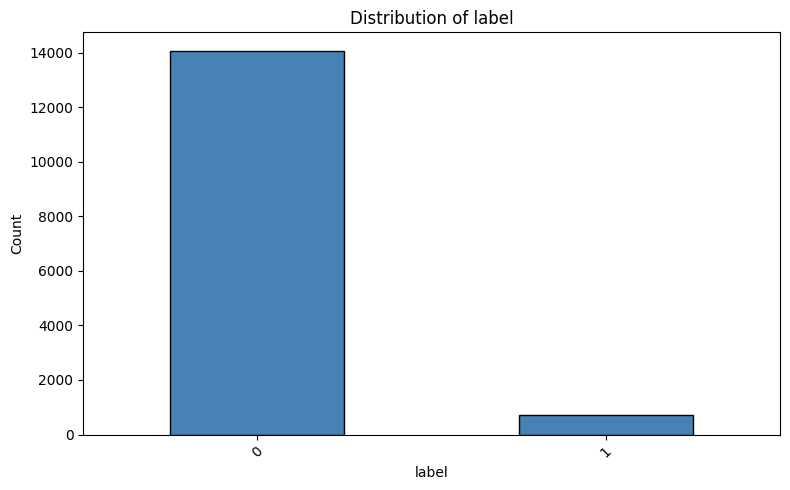


Numeric columns: ['time', 'label']


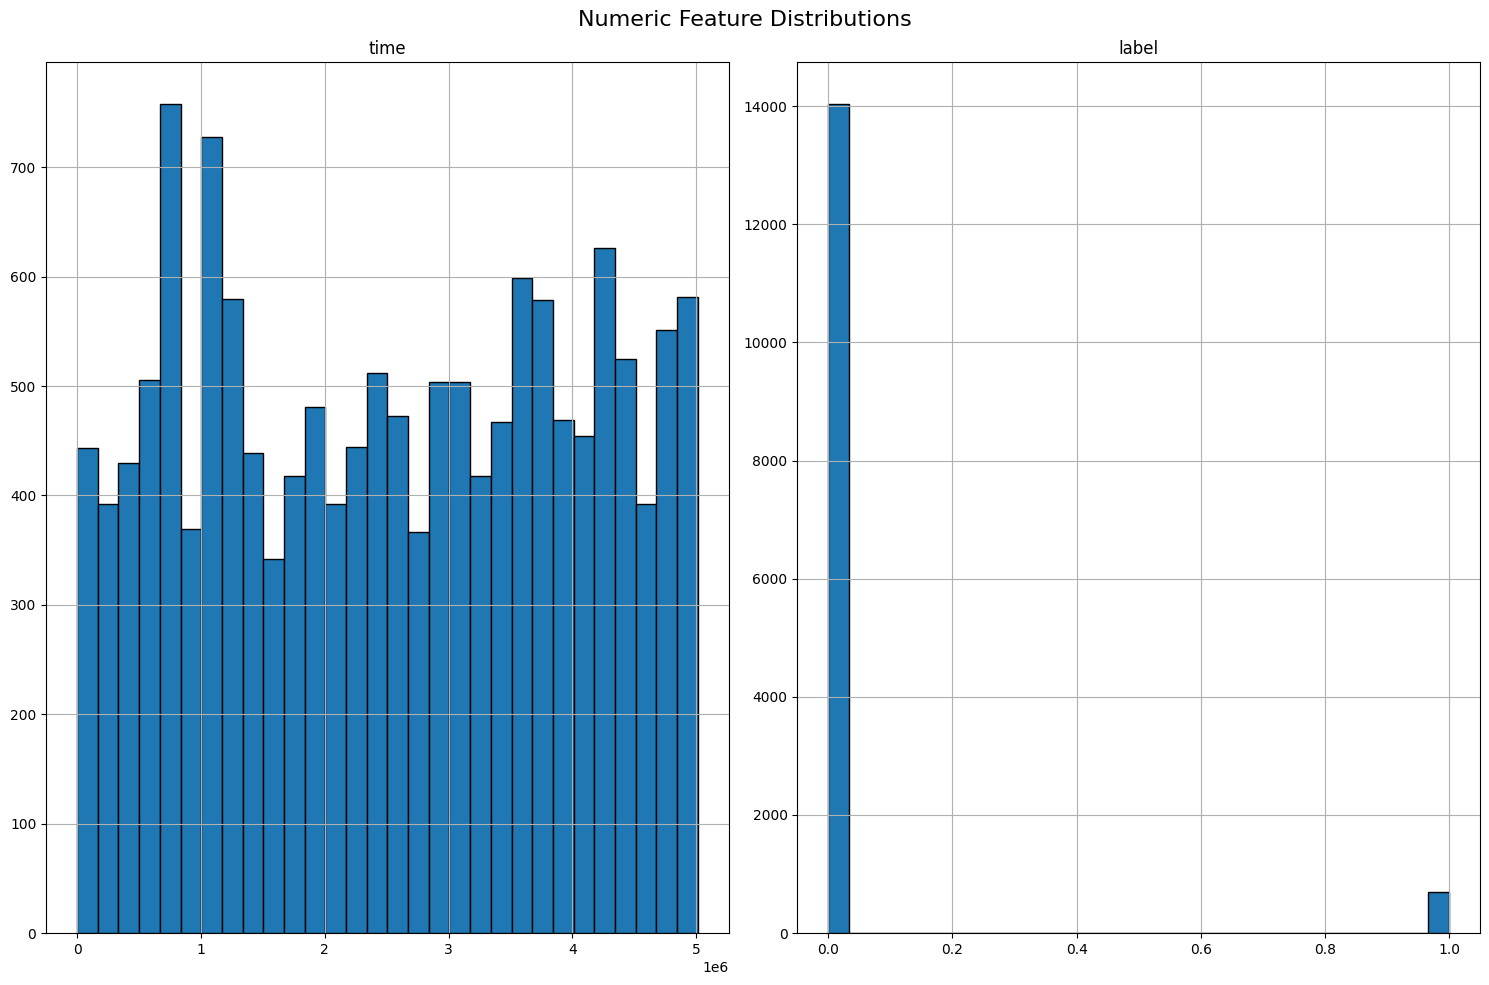

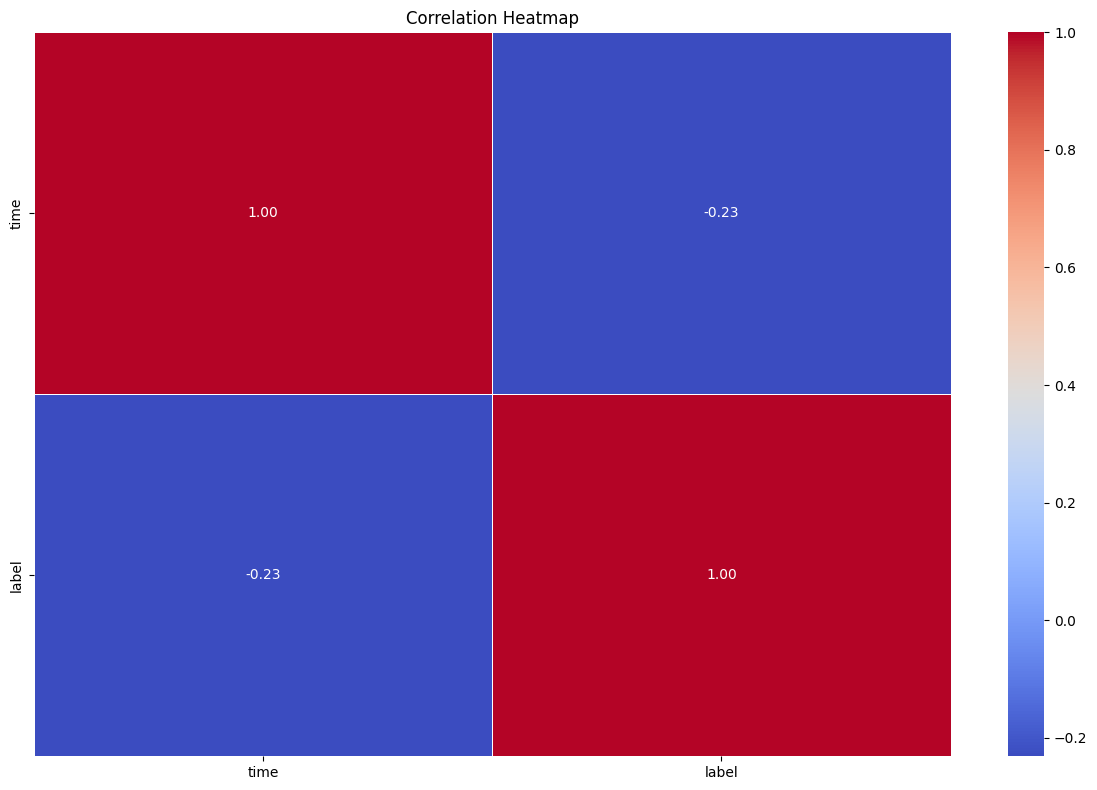


Categorical columns: ['src_user', 'dst_user', 'src_pc', 'dst_pc', 'auth_type', 'logon_type', 'auth_orient', 'success']

Value counts for 'src_user':
 src_user
U66@DOM1                272
U22@DOM1                241
ANONYMOUS LOGON@C586    213
C1114$@DOM1             107
C599$@DOM1              101
C104$@DOM1               95
C538$@DOM1               77
C585$@DOM1               76
C743$@DOM1               75
C1794$@DOM1              74
Name: count, dtype: int64


C:\Users\Christopher Chong\AppData\Local\Temp\ipykernel_38712\2514398063.py:53: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


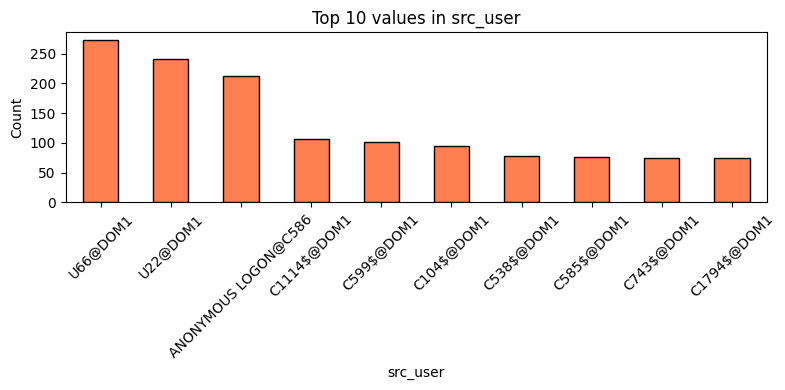


Value counts for 'dst_user':
 dst_user
U66@DOM1                272
U22@DOM1                241
ANONYMOUS LOGON@C586    213
C1114$@DOM1             107
C599$@DOM1              101
C104$@DOM1               95
C538$@DOM1               77
C585$@DOM1               76
C743$@DOM1               75
C1794$@DOM1              74
Name: count, dtype: int64


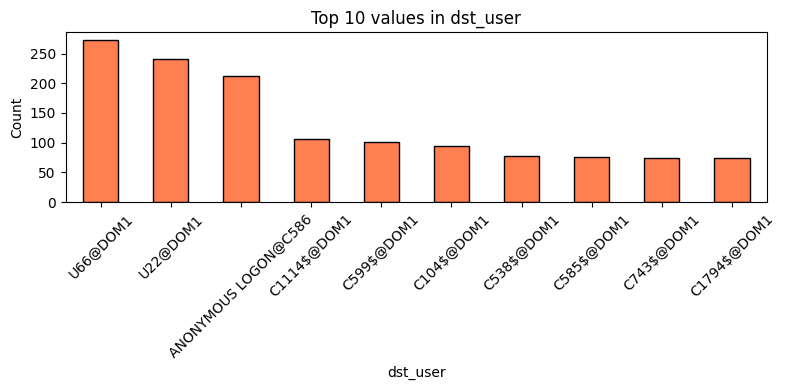


Value counts for 'src_pc':
 src_pc
C586      721
C17693    670
C612      511
C467      509
C625      497
C529      472
C1065     462
C457      445
C528      361
C2106     254
Name: count, dtype: int64


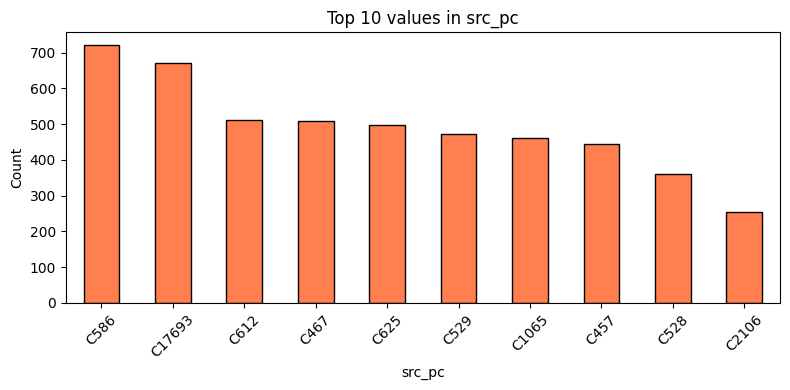


Value counts for 'dst_pc':
 dst_pc
C586     1567
C612     1033
C529      992
C467      980
C457      929
C625      921
C1065     897
C528      715
C2106     456
C2162     323
Name: count, dtype: int64


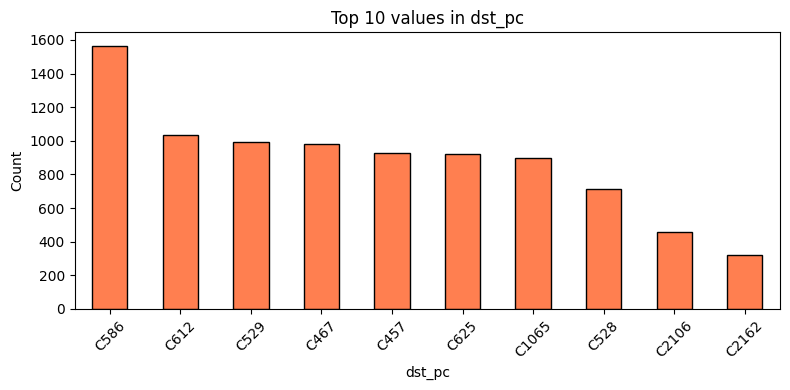


Value counts for 'auth_type':
 auth_type
?                                        7833
Kerberos                                 4797
NTLM                                     1377
Negotiate                                 727
MICROSOFT_AUTHENTICATION_PACKAGE_V1_0       7
MICROSOFT_AUTHENTICATION_PACKAGE_V1         1
MICROSOFT_AUTHENTICATION_PACKAGE_V1_        1
Name: count, dtype: int64


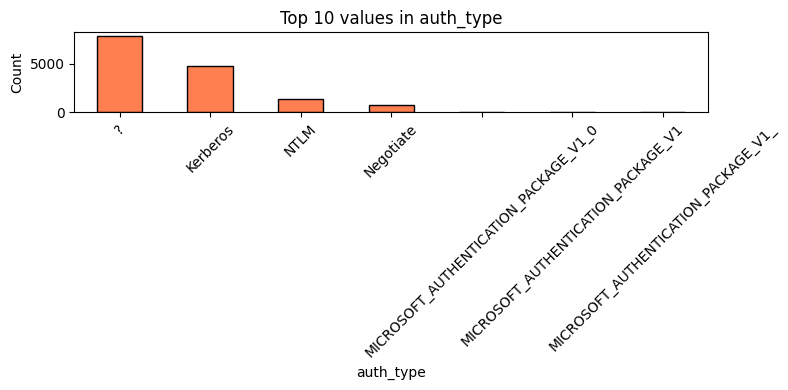

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('./data/cyber1/labeled_sample.csv')

# Basic info
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nBasic Statistics:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Distribution of target/label column
label_col = [col for col in df.columns if 'label' in col.lower()]
if label_col:
    print(f"\nLabel column: {label_col[0]}")
    print(df[label_col[0]].value_counts())
    
    plt.figure(figsize=(8, 5))
    df[label_col[0]].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Distribution of {label_col[0]}')
    plt.xlabel(label_col[0])
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Numeric columns distribution
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns: {numeric_cols}")

if numeric_cols:
    df[numeric_cols].hist(figsize=(15, 10), bins=30, edgecolor='black')
    plt.suptitle('Numeric Feature Distributions', fontsize=16)
    plt.tight_layout()
    plt.show()

# Correlation heatmap
if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 8))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns: {cat_cols}")

for col in cat_cols[:5]:  # limit to first 5 categorical columns
    print(f"\nValue counts for '{col}':\n", df[col].value_counts().head(10))
    plt.figure(figsize=(8, 4))
    df[col].value_counts().head(10).plot(kind='bar', color='coral', edgecolor='black')
    plt.title(f'Top 10 values in {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Total auth events: 14,743
Unique source users: 7,889 | destination users: 7,916
Unique source PCs: 4,753 | destination PCs: 2,005
Self-authentication ratio (src_user == dst_user): 98.41%

Top 10 user -> user flows:
src_user              dst_user            
U66@DOM1              U66@DOM1                272
U22@DOM1              U22@DOM1                241
ANONYMOUS LOGON@C586  ANONYMOUS LOGON@C586    213
C1114$@DOM1           C1114$@DOM1             107
C599$@DOM1            C599$@DOM1              101
C104$@DOM1            C104$@DOM1               95
C538$@DOM1            C538$@DOM1               77
C585$@DOM1            C585$@DOM1               76
C743$@DOM1            C743$@DOM1               75
C1794$@DOM1           C1794$@DOM1              74
Name: count, dtype: int64

Top 10 PC -> PC flows:
src_pc  dst_pc
C586    C586      720
C612    C612      511
C467    C467      507
C625    C625      494
C529    C529      471
C1065   C1065     458
C457    C457      441
C528    C528      361
C

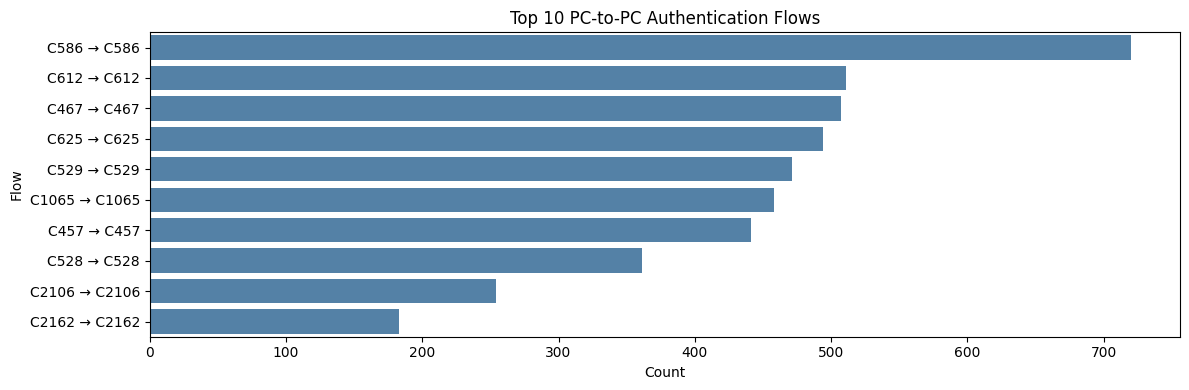

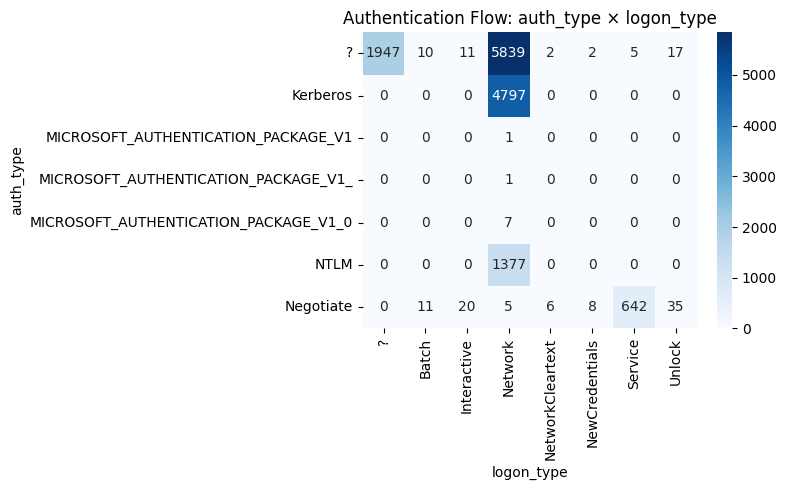

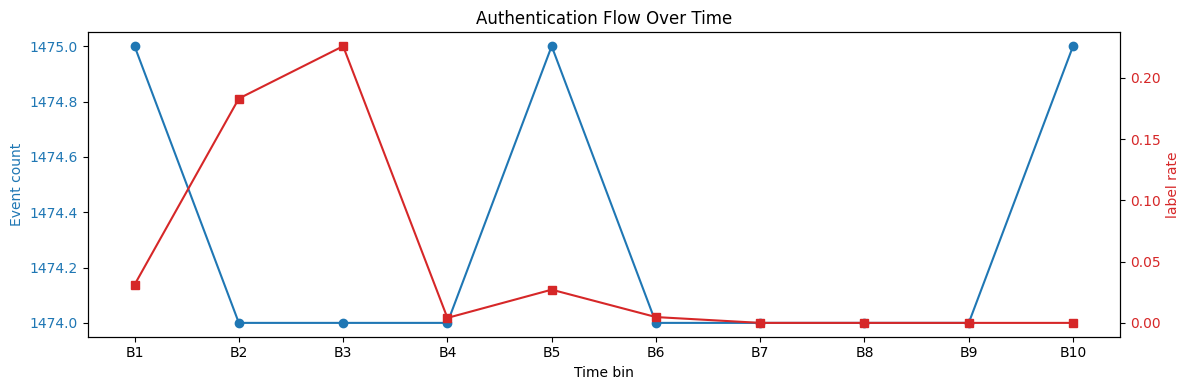

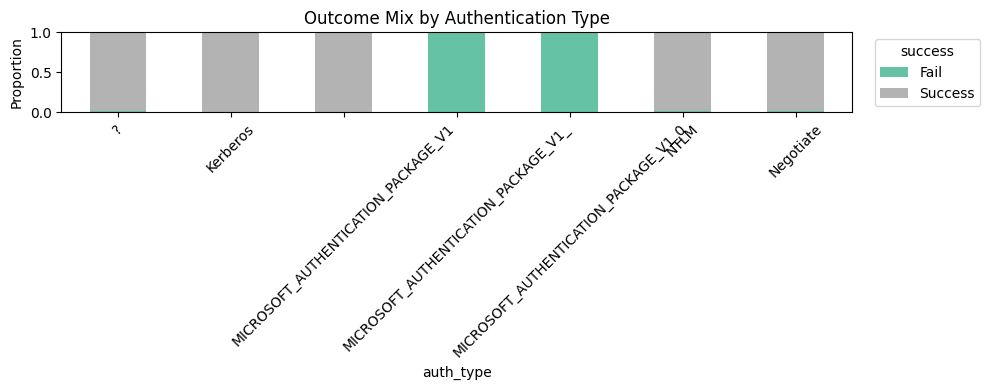

In [30]:
# Authentication flow analysis

df_flow = df.sort_values("time").copy()
label_name = label_col[0] if label_col else None

# Basic flow metrics
total_events = len(df_flow)
unique_src_users = df_flow["src_user"].nunique()
unique_dst_users = df_flow["dst_user"].nunique()
unique_src_pcs = df_flow["src_pc"].nunique()
unique_dst_pcs = df_flow["dst_pc"].nunique()
self_user_auth_ratio = (df_flow["src_user"] == df_flow["dst_user"]).mean()

print(f"Total auth events: {total_events:,}")
print(f"Unique source users: {unique_src_users:,} | destination users: {unique_dst_users:,}")
print(f"Unique source PCs: {unique_src_pcs:,} | destination PCs: {unique_dst_pcs:,}")
print(f"Self-authentication ratio (src_user == dst_user): {self_user_auth_ratio:.2%}")

# Top user-to-user and PC-to-PC flows
top_user_flows = (
    df_flow.groupby(["src_user", "dst_user"])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename("count")
)
top_pc_flows = (
    df_flow.groupby(["src_pc", "dst_pc"])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename("count")
)

print("\nTop 10 user -> user flows:")
print(top_user_flows)

print("\nTop 10 PC -> PC flows:")
print(top_pc_flows)

# Time-binned behavior (10 bins across timeline)
df_flow["time_bin"] = pd.qcut(df_flow["time"], q=10, duplicates="drop")
events_per_bin = df_flow.groupby("time_bin", observed=False).size()

if label_name:
    anomaly_rate_per_bin = df_flow.groupby("time_bin", observed=False)[label_name].mean()

# Plot 1: Top PC->PC flows
plt.figure(figsize=(12, 4))
pc_labels = [f"{s} → {d}" for s, d in top_pc_flows.index]
sns.barplot(x=top_pc_flows.values, y=pc_labels, color="steelblue")
plt.title("Top 10 PC-to-PC Authentication Flows")
plt.xlabel("Count")
plt.ylabel("Flow")
plt.tight_layout()
plt.show()

# Plot 2: Auth type vs Logon type heatmap (flow structure)
auth_logon = pd.crosstab(df_flow["auth_type"], df_flow["logon_type"])
plt.figure(figsize=(8, 5))
sns.heatmap(auth_logon, annot=True, fmt="d", cmap="Blues")
plt.title("Authentication Flow: auth_type × logon_type")
plt.tight_layout()
plt.show()

# Plot 3: Temporal volume and anomaly rate
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(events_per_bin.values, marker="o", color="tab:blue", label="Events")
ax1.set_xlabel("Time bin")
ax1.set_ylabel("Event count", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xticks(range(len(events_per_bin)))
ax1.set_xticklabels([f"B{i+1}" for i in range(len(events_per_bin))], rotation=0)

if label_name:
    ax2 = ax1.twinx()
    ax2.plot(anomaly_rate_per_bin.values, marker="s", color="tab:red", label=f"{label_name} rate")
    ax2.set_ylabel(f"{label_name} rate", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Authentication Flow Over Time")
plt.tight_layout()
plt.show()

# Plot 4: Success distribution by auth_type
success_dist = pd.crosstab(df_flow["auth_type"], df_flow["success"], normalize="index")
success_dist.plot(kind="bar", stacked=True, figsize=(10, 4), colormap="Set2")
plt.title("Outcome Mix by Authentication Type")
plt.ylabel("Proportion")
plt.xlabel("auth_type")
plt.xticks(rotation=45)
plt.legend(title="success", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [31]:
# Detect anomalous authentication flows (flow-level scoring)

flow_cols = ["src_user", "dst_user", "src_pc", "dst_pc", "auth_type", "logon_type"]

anomalous_flow_df = (
    df_flow.groupby(flow_cols, observed=False)
    .agg(
        flow_count=("time", "size"),
        fail_count=("success", lambda s: (s == "Fail").sum()),
        unique_bins=("time_bin", "nunique"),
        label_rate=(label_name, "mean") if label_name else ("time", "size"),
    )
    .reset_index()
)

# If label_name was not available, remove placeholder behavior
if not label_name:
    anomalous_flow_df = anomalous_flow_df.drop(columns=["label_rate"])

# Derived metrics
anomalous_flow_df["fail_rate"] = anomalous_flow_df["fail_count"] / anomalous_flow_df["flow_count"]
anomalous_flow_df["flow_freq"] = anomalous_flow_df["flow_count"] / total_events
anomalous_flow_df["rarity_score"] = -np.log(anomalous_flow_df["flow_freq"].clip(lower=1e-12))

# Composite anomaly score
if label_name:
    anomalous_flow_df["anomaly_score"] = (
        0.45 * anomalous_flow_df["rarity_score"]
        + 0.30 * anomalous_flow_df["fail_rate"]
        + 0.25 * anomalous_flow_df["label_rate"]
    )
else:
    anomalous_flow_df["anomaly_score"] = (
        0.70 * anomalous_flow_df["rarity_score"]
        + 0.30 * anomalous_flow_df["fail_rate"]
    )

# Flag top 1% highest-scoring flows
threshold = anomalous_flow_df["anomaly_score"].quantile(0.99)
anomalous_flows = anomalous_flow_df[anomalous_flow_df["anomaly_score"] >= threshold].copy()
anomalous_flows = anomalous_flows.sort_values("anomaly_score", ascending=False)

print(f"Detected anomalous flows: {len(anomalous_flows)} (threshold={threshold:.4f})")
display(
    anomalous_flows.head(20)[
        flow_cols + ["flow_count", "fail_count", "fail_rate"] + (["label_rate"] if label_name else []) + ["anomaly_score"]
    ]
)

Detected anomalous flows: 384 (threshold=4.5693)


,src_user,dst_user,src_pc,dst_pc,auth_type,logon_type,flow_count,fail_count,fail_rate,label_rate,anomaly_score
11510,U8686@?,U8686@?,C18510,C18510,?,?,1,1,1.0,0.0,4.619336
11571,U8849@?,U8849@?,C625,C625,?,?,1,1,1.0,0.0,4.619336
11591,U8922@?,U8922@?,C22546,C22546,?,?,1,1,1.0,0.0,4.619336
11593,U8929@?,U8929@?,C19037,C19037,?,?,1,1,1.0,0.0,4.619336
11643,U8@DOM1,U8@DOM1,C419,C419,NTLM,Network,1,1,1.0,0.0,4.619336
4632,C2653$@DOM1,C2653$@DOM1,C2653,C2653,?,?,1,1,1.0,0.0,4.619336
4660,C26953$@DOM1,C26953$@DOM1,C26953,C529,NTLM,Network,1,1,1.0,0.0,4.619336
5378,C4033$@DOM1,C4033$@DOM1,C4033,C4033,?,?,1,1,1.0,0.0,4.619336
5663,C4681$@DOM1,C4681$@DOM1,C4682,C3718,Kerberos,Network,1,1,1.0,0.0,4.619336
5751,C4858$@DOM1,C4858$@DOM1,C4858,C4858,?,?,1,1,1.0,0.0,4.619336


In [32]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

# Features for Isolation Forest (use existing df_flow and label_name)
if not label_name:
    raise ValueError("No label column found. 'label_name' is required for evaluation.")

feature_cols = [
    "time", "src_user", "dst_user", "src_pc", "dst_pc",
    "auth_type", "logon_type", "auth_orient", "success"
]

X = df_flow[feature_cols].copy()
y = df_flow[label_name].astype(int).copy()

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=X.select_dtypes(include="object").columns, dummy_na=False)

# Use label prevalence as contamination estimate (clipped for valid range)
contamination = float(np.clip(y.mean(), 0.001, 0.5))

iso = IsolationForest(
    n_estimators=300,
    contamination=contamination,
    random_state=42,
    n_jobs=-1
)

iso.fit(X_encoded) # Fit on entire dataset for unsupervised detection

# Predictions: -1 = anomaly, 1 = normal
y_pred = (iso.predict(X_encoded) == -1).astype(int)

# Anomaly score (higher => more anomalous)
y_score = -iso.decision_function(X_encoded)

print(f"Dataset size: {len(X_encoded):,}")
print(f"Label prevalence: {y.mean():.4f} | contamination used: {contamination:.4f}")
print("\nClassification Report:")
print("(label=0: Normal  |  label=1: Red Team Attack)")
print(classification_report(y, y_pred, digits=4, target_names=["Normal (0)", "Attack (1)"]))

cm = confusion_matrix(y, y_pred)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
print("Confusion Matrix:")
display(cm_df)

print(f"ROC-AUC (attack class, label=1): {roc_auc_score(y, y_score):.4f}")
print(f"PR-AUC  (attack class, label=1): {average_precision_score(y, y_score):.4f}")

C:\Users\Christopher Chong\AppData\Local\Temp\ipykernel_38712\415936413.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_encoded = pd.get_dummies(X, columns=X.select_dtypes(include="object").columns, dummy_na=False)


Dataset size: 14,743
Label prevalence: 0.0476 | contamination used: 0.0476

Classification Report:
(label=0: Normal  |  label=1: Red Team Attack)
              precision    recall  f1-score   support

  Normal (0)     0.9513    0.9513    0.9513     14041
  Attack (1)     0.0256    0.0256    0.0256       702

    accuracy                         0.9072     14743
   macro avg     0.4885    0.4885    0.4885     14743
weighted avg     0.9072    0.9072    0.9072     14743

Confusion Matrix:


,Pred 0,Pred 1
Actual 0,13357,684
Actual 1,684,18


ROC-AUC (attack class, label=1): 0.6145
PR-AUC  (attack class, label=1): 0.0603


In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Local Outlier Factor (LOF) + LSTM Autoencoder


# -----------------------------
# 1) Local Outlier Factor
# -----------------------------
lof = LocalOutlierFactor(
    n_neighbors=35,
    contamination=contamination,
    metric="euclidean",
    n_jobs=-1
)

# LOF output: -1 anomaly, 1 normal
y_pred_lof = (lof.fit_predict(X_encoded) == -1).astype(int)
y_score_lof = -lof.negative_outlier_factor_  # higher => more anomalous

print("=== Local Outlier Factor ===")
print("(label=0: Normal  |  label=1: Red Team Attack)")
print(classification_report(y, y_pred_lof, digits=4, target_names=["Normal (0)", "Attack (1)"]))
print(f"ROC-AUC (attack class, label=1): {roc_auc_score(y, y_score_lof):.4f}")
print(f"PR-AUC  (attack class, label=1): {average_precision_score(y, y_score_lof):.4f}")

cm_lof = confusion_matrix(y, y_pred_lof)
display(pd.DataFrame(cm_lof, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))


# -----------------------------
# 2) LSTM Autoencoder
# -----------------------------
try:

    df_seq = df_flow.sort_values("time").copy()

    # Use existing feature_cols; encode object columns to integer codes
    X_lstm_df = df_seq[feature_cols].copy()
    for c in X_lstm_df.select_dtypes(include="object").columns:
        X_lstm_df[c] = X_lstm_df[c].astype("category").cat.codes

    scaler = MinMaxScaler()
    X_lstm_scaled = scaler.fit_transform(X_lstm_df).astype("float32")

    # Build sliding windows
    window = 10
    n = len(X_lstm_scaled) - window + 1
    X_seq = np.stack([X_lstm_scaled[i:i + window] for i in range(n)], axis=0)

    # Window label = anomaly if any event in window is anomaly
    y_seq = (
        df_seq[label_name]
        .rolling(window)
        .max()
        .dropna()
        .astype(int)
        .values
    )

    # Train autoencoder only on normal windows
    X_seq_train = X_seq[y_seq == 0]
    timesteps, n_features = X_seq.shape[1], X_seq.shape[2]

    inp = Input(shape=(timesteps, n_features))
    x = LSTM(32, activation="tanh", return_sequences=False)(inp)
    x = RepeatVector(timesteps)(x)
    x = LSTM(32, activation="tanh", return_sequences=True)(x)
    out = TimeDistributed(Dense(n_features))(x)

    lstm_ae = Model(inp, out)
    lstm_ae.compile(optimizer="adam", loss="mse")

    es = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
    lstm_ae.fit(
        X_seq_train, X_seq_train,
        epochs=8,
        batch_size=128,
        validation_split=0.1,
        callbacks=[es],
        verbose=0
    )

    # Reconstruction error
    X_seq_hat = lstm_ae.predict(X_seq, verbose=0)
    recon_err = np.mean((X_seq - X_seq_hat) ** 2, axis=(1, 2))

    # Threshold from normal-train errors at (1 - contamination) quantile
    X_seq_train_hat = lstm_ae.predict(X_seq_train, verbose=0)
    train_err = np.mean((X_seq_train - X_seq_train_hat) ** 2, axis=(1, 2))
    thr_lstm = np.quantile(train_err, 1 - contamination)

    y_pred_lstm = (recon_err >= thr_lstm).astype(int)
    y_score_lstm = recon_err

    print("\n=== LSTM Autoencoder (window-level) ===")
    print("(label=0: Normal window  |  label=1: Window contains Attack)")
    print(classification_report(y_seq, y_pred_lstm, digits=4, target_names=["Normal (0)", "Attack (1)"]))
    print(f"ROC-AUC (score-based): {roc_auc_score(y_seq, y_score_lstm):.4f}")
    print(f"PR-AUC  (score-based): {average_precision_score(y_seq, y_score_lstm):.4f}")

    cm_lstm = confusion_matrix(y_seq, y_pred_lstm)
    display(pd.DataFrame(cm_lstm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))

except Exception as e:
    print("LSTM step skipped. TensorFlow/Keras is not available or failed to run.")
    print("Error:", e)

SyntaxError: expected 'except' or 'finally' block (4196962577.py, line 101)

In [ ]:
# ============================================================
# Ensemble: Score Average + Majority Vote
# ============================================================
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)

# --- helper: normalise any score array to [0, 1] ---
def norm_score(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-12)   # 1e-12 avoids divide-by-zero if all scores equal

# --- check whether LSTM ran successfully ---
# LSTM scores exist only if the try-block in the previous cell completed
try:
    _ = y_score_lstm
    lstm_available = True
except NameError:
    lstm_available = False

# --- collect scores and binary predictions from each detector ---
# IF and LOF both produce one value per event, so they align directly with y
base_scores = {"IsolationForest": y_score, "LOF": y_score_lof}
base_preds  = {"IsolationForest": y_pred,  "LOF": y_pred_lof}

if lstm_available:
    # LSTM works on sliding windows so it has (n_events - window + 1) outputs
    # Pad the front with zeros so the array length matches y
    pad = len(y) - len(y_score_lstm)                                  # = window - 1 = 9
    base_scores["LSTM"] = np.concatenate([np.zeros(pad), y_score_lstm])
    base_preds["LSTM"]  = np.concatenate([np.zeros(pad, dtype=int),  y_pred_lstm])
    print(f"LSTM included — padded {pad} events at start")
else:
    print("LSTM not available — using IF + LOF only")

detector_names = list(base_scores.keys())   # e.g. ["IsolationForest", "LOF"] or with "LSTM"

# ── 1. Normalised Score Average ──────────────────────────────────────────────
# Normalise each detector score to [0,1] so different score ranges contribute equally
norm_matrix   = np.stack([norm_score(base_scores[k]) for k in detector_names], axis=1)

# Average normalised scores across detectors — higher = more likely anomalous
ensemble_norm = norm_matrix.mean(axis=1)

# Flag the top-contamination fraction as anomalies (same threshold logic as IF/LOF)
y_pred_avg    = (ensemble_norm >= np.quantile(ensemble_norm, 1 - contamination)).astype(int)

# ── 2. Majority Vote ─────────────────────────────────────────────────────────
# Stack each detector binary prediction (0 = normal, 1 = anomaly) into a matrix
pred_matrix   = np.stack([base_preds[k] for k in detector_names], axis=1)

# Count how many detectors flagged each event — used as the continuous score for AUC
vote_score    = pred_matrix.sum(axis=1).astype(float)

# Flag as anomaly only if strictly more than half the detectors agree
y_pred_vote   = (vote_score > len(detector_names) / 2).astype(int)

# ── Evaluate both methods ────────────────────────────────────────────────────
methods = {
    "Score Average": (y_pred_avg,  ensemble_norm),   # avg normalised score as continuous ranking
    "Majority Vote": (y_pred_vote, vote_score),      # vote count as continuous ranking for AUC
}

for name, (y_p, y_s) in methods.items():
    print(f"=== {name} ===")
    print(classification_report(y, y_p, digits=4))              # precision/recall/f1 per class
    print(f"ROC-AUC : {roc_auc_score(y, y_s):.4f}")           # ranking quality
    print(f"PR-AUC  : {average_precision_score(y, y_s):.4f}")  # better metric for imbalanced data
    cm = confusion_matrix(y, y_p)
    display(pd.DataFrame(cm, index=["Actual 0","Actual 1"], columns=["Pred 0","Pred 1"]))

# ── Summary table: individuals first, then ensembles ─────────────────────────
rows = []

# Individual detectors first
for k in detector_names:
    rows.append({"Method":    k,
                 "Precision": precision_score(y, base_preds[k], zero_division=0),
                 "Recall":    recall_score(y, base_preds[k], zero_division=0),
                 "F1":        f1_score(y, base_preds[k], zero_division=0),
                 "ROC-AUC":   roc_auc_score(y, base_scores[k]),
                 "PR-AUC":    average_precision_score(y, base_scores[k])})

# Ensemble methods after
for name, (y_p, y_s) in methods.items():
    rows.append({"Method":    name,
                 "Precision": precision_score(y, y_p, zero_division=0),
                 "Recall":    recall_score(y, y_p, zero_division=0),
                 "F1":        f1_score(y, y_p, zero_division=0),
                 "ROC-AUC (label=1)":   roc_auc_score(y, y_s),
                 "PR-AUC (label=1)":    average_precision_score(y, y_s)})

summary = pd.DataFrame(rows).set_index("Method").round(4)
print("=== Summary ===")
display(summary)   # individuals first, then ensembles — no sorting


SyntaxError: unterminated f-string literal (detected at line 69) (2637291282.py, line 69)